In [1]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Merge regions based on historic provinces or other criteria.

In [2]:
gadm_files = [os.path.join(root, file)
              for root, dirs, files in os.walk("data/_data/gadm/")
              for file in files if file.startswith("gadm")]
print(gadm_files)

['data/_data/gadm/gadm41_GBR_0.cpg', 'data/_data/gadm/gadm41_GBR_0.dbf', 'data/_data/gadm/gadm41_GBR_0.prj', 'data/_data/gadm/gadm41_GBR_0.shp', 'data/_data/gadm/gadm41_GBR_0.shx', 'data/_data/gadm/gadm41_GBR_1.cpg', 'data/_data/gadm/gadm41_GBR_1.dbf', 'data/_data/gadm/gadm41_GBR_1.prj', 'data/_data/gadm/gadm41_GBR_1.shp', 'data/_data/gadm/gadm41_GBR_1.shx', 'data/_data/gadm/gadm41_GBR_2.cpg', 'data/_data/gadm/gadm41_GBR_2.dbf', 'data/_data/gadm/gadm41_GBR_2.prj', 'data/_data/gadm/gadm41_GBR_2.shp', 'data/_data/gadm/gadm41_GBR_2.shx', 'data/_data/gadm/gadm41_GBR_3.cpg', 'data/_data/gadm/gadm41_GBR_3.dbf', 'data/_data/gadm/gadm41_GBR_3.prj', 'data/_data/gadm/gadm41_GBR_3.shp', 'data/_data/gadm/gadm41_GBR_3.shx', 'data/_data/gadm/gadm41_GBR_4.cpg', 'data/_data/gadm/gadm41_GBR_4.dbf', 'data/_data/gadm/gadm41_GBR_4.prj', 'data/_data/gadm/gadm41_GBR_4.shp', 'data/_data/gadm/gadm41_GBR_4.shx']


In [3]:
uk_level0 = gpd.read_file("data/_data/gadm/gadm41_GBR_0.shp") #вся країна
uk_level1 = gpd.read_file("data/_data/gadm/gadm41_GBR_1.shp") #головні складові (історичні провінції) 
uk_level2 = gpd.read_file("data/_data/gadm/gadm41_GBR_2.shp") #регіони
uk_level3 = gpd.read_file("data/_data/gadm/gadm41_GBR_3.shp") #райони 
uk_level4 = gpd.read_file("data/_data/gadm/gadm41_GBR_4.shp") #менші територіальні одиниці(села,міста і тд)

In [4]:
uk_level2["NAME_1"] = uk_level2["NAME_1"].replace("NA", "England")
uk_merged = uk_level2.dissolve(by="NAME_1", as_index=False)
uk_merged.head()

,NAME_1,geometry,GID_2,GID_0,COUNTRY,GID_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
0,England,"MULTIPOLYGON (((-6.39842 49.86553, -6.39845 49...",GBR.1.2_1,GBR,United Kingdom,GBR.1_1,NA,Bath and North East Somerset,NA,NA,Unitary Authority,Unitary Authority,NA,GB.BN
1,Northern Ireland,"MULTIPOLYGON (((-5.88543 54.19814, -5.88544 54...",GBR.2.1_1,GBR,United Kingdom,GBR.2_1,NA,Antrim and Newtownabbey,NA,NA,District,District,NA,GB.AT
2,Scotland,"MULTIPOLYGON (((-7.63058 56.78917, -7.63085 56...",GBR.3.1_1,GBR,United Kingdom,GBR.3_1,NA,Aberdeen City,NA,NA,Unitary District (City),Unitary District (City),NA,GB.AR
3,Wales,"MULTIPOLYGON (((-4.69838 51.64117, -4.69788 51...",GBR.4.4_1,GBR,United Kingdom,GBR.4_1,NA,Caerphilly,NA,NA,Unitary Authority,Unitary Authority,NA,GB.CP


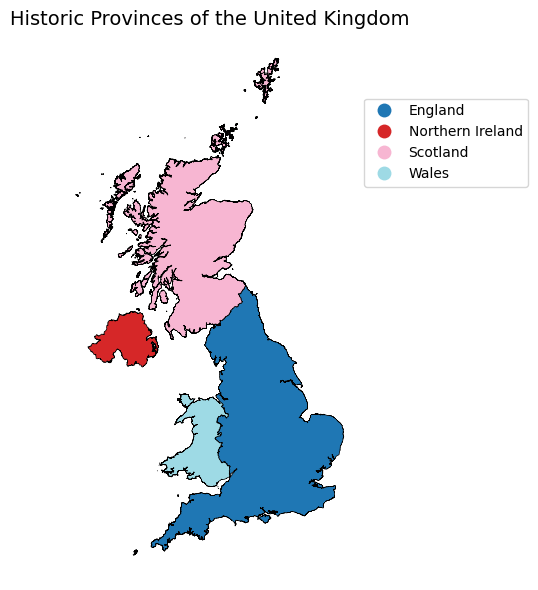

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 6))
uk_merged.plot(column="NAME_1", 
                cmap="tab20",
                legend=True,     
                ax=ax,
                edgecolor="black",
                legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.8)},
                linewidth=0.5)

ax.set_title("Historic Provinces of the United Kingdom", fontsize=14)
ax.axis("off")
plt.tight_layout() 
plt.show()

# Geocode centroids for each region and the whole country.

In [6]:
uk_level2.crs.name
uk_level0.crs.name

'WGS 84'

In [7]:
uk_level0_projected = uk_level0.to_crs(epsg=3857)
uk_level2_projected = uk_level2.to_crs(epsg=3857)

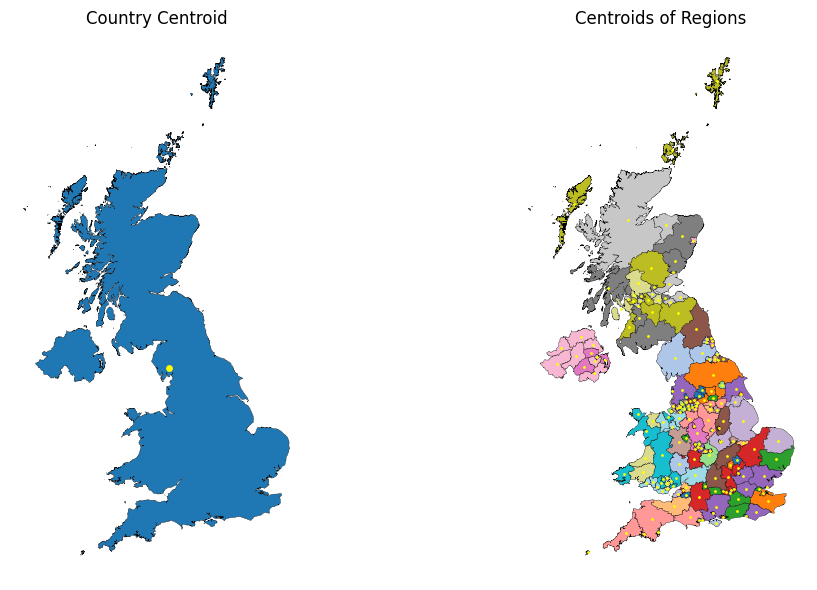

101


In [8]:
fig, (ax0, ax2) = plt.subplots(1, 2, figsize=(12, 6))

uk_level0_projected.plot(
                ax=ax0,
                cmap="tab20",
                edgecolor="black",
                linewidth=0.2)
uk_level0_projected.centroid.plot( 
                ax=ax0, 
                markersize=15, 
                color="yellow")
ax0.set_title("Country Centroid")
ax0.axis("off")

uk_level2_projected.plot(
                ax=ax2,
                cmap="tab20",
                edgecolor="black",
                linewidth=0.2)
uk_level2_projected.centroid.plot(
                ax=ax2, 
                markersize=1, 
                color="yellow")
ax2.set_title("Centroids of Regions")
ax2.axis("off")
plt.tight_layout()
plt.show()

print(uk_level2["NAME_2"].nunique())

# Plot a color map based on average GRDP of the region. 

In [9]:
gadm_files = [os.path.join(root, file)
              for root, dirs, files in os.walk("data/_data/gadm_ua/")
              for file in files if file.startswith("gadm")]
print(gadm_files)
gadm_files_level2 = [file for file in gadm_files if "2.shp" in file]
shps = [gpd.read_file(shp) for shp in gadm_files_level2]
ukr_shp = gpd.GeoDataFrame(pd.concat(shps, ignore_index=True))

df = pd.read_csv("data/_data/VRP_ reg_04_20_II_ue.csv")


['data/_data/gadm_ua/gadm41_UKR_0.cpg', 'data/_data/gadm_ua/gadm41_UKR_0.dbf', 'data/_data/gadm_ua/gadm41_UKR_0.prj', 'data/_data/gadm_ua/gadm41_UKR_0.shp', 'data/_data/gadm_ua/gadm41_UKR_0.shx', 'data/_data/gadm_ua/gadm41_UKR_1.cpg', 'data/_data/gadm_ua/gadm41_UKR_1.dbf', 'data/_data/gadm_ua/gadm41_UKR_1.prj', 'data/_data/gadm_ua/gadm41_UKR_1.shp', 'data/_data/gadm_ua/gadm41_UKR_1.shx', 'data/_data/gadm_ua/gadm41_UKR_2.cpg', 'data/_data/gadm_ua/gadm41_UKR_2.dbf', 'data/_data/gadm_ua/gadm41_UKR_2.prj', 'data/_data/gadm_ua/gadm41_UKR_2.shp', 'data/_data/gadm_ua/gadm41_UKR_2.shx']


In [10]:
ua_names = ukr_shp["NL_NAME_1"].unique()
print(ua_names)

df_names = df["Unnamed: 0"].unique()
print(df_names)


['?' 'Черкаська' 'Чернігівська' 'Чернівецька' 'Крим' 'Дніпропетро́вська'
 'Доне́цька' 'Івано-Франківська' 'Харківська' 'Херсонська' 'Хмельницька'
 'Київська' 'Київ' 'Кіровоградська' 'Львівська' 'Львівщина' 'Луганська'
 'Миколаївська' 'Одеська' 'Полтавська' 'Рівненська' 'Севастополь'
 'Сумська' 'Тернопільська' 'Вінницька' 'Волинська' 'Закарпатська'
 'Запорізька' 'Житомирська']
['Україна' 'Автономна\n Республіка Крим' 'області' 'Вінницька' 'Волинська'
 'Дніпропетровська' 'Донецька' 'Житомирська' 'Закарпатська' 'Запорізька'
 'Івано-Франківська' 'Київська' 'Кіровоградська' 'Луганська' 'Львівська'
 'Миколаївська' 'Одеська' 'Полтавська' 'Рівненська' 'Сумська'
 'Тернопільська' 'Харківська' 'Херсонська' 'Хмельницька' 'Черкаська'
 'Чернівецька' 'Чернігівська' 'м.Київ' 'м.Севастополь']


In [11]:
name_corrections = {
    '?':'м.Київ',
    'Київ': 'м.Київ',
    'Севастополь' : 'м.Севастополь',
    'Дніпропетро́вська': 'Дніпропетровська',
    'Доне́цька': 'Донецька',
    'Львівщина': 'Львівська',
    'Крим': 'Автономна\n Республіка Крим'}
ukr_shp["NL_NAME_1"] = ukr_shp["NL_NAME_1"].replace(name_corrections)


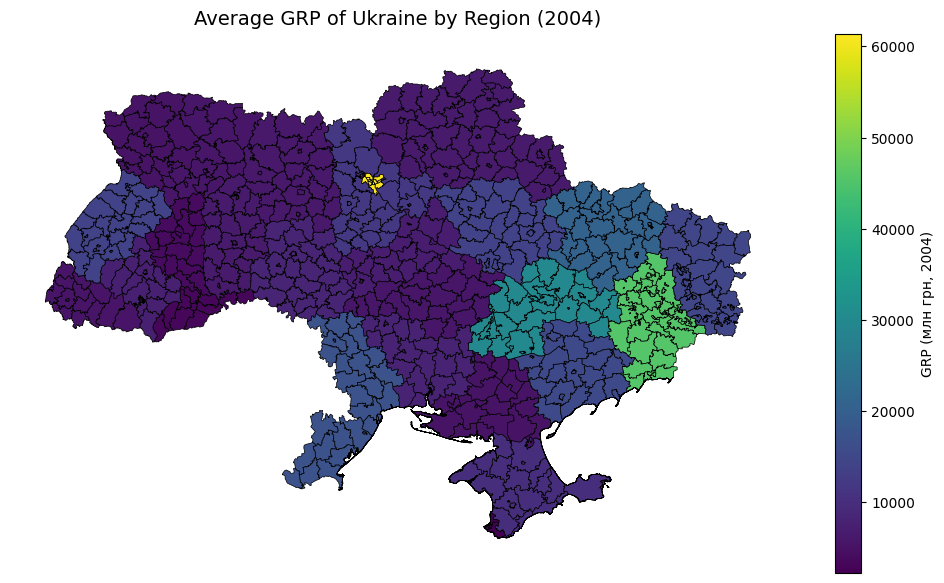

In [12]:
ukraine_merged = ukr_shp.merge(df, left_on="NL_NAME_1", right_on="Unnamed: 0", how="left")
fig, ax = plt.subplots(figsize=(10, 8))
ukraine_merged.plot(
    column="2004",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    legend_kwds={
        'label': "GRP (млн грн, 2004)",
        'orientation': "vertical",
        'shrink': 0.7},
    ax=ax)

ax.set_title("Average GRP of Ukraine by Region (2004)", fontsize=14, pad=15)
ax.axis("off")
plt.tight_layout()
plt.show()